In [2]:
#!/home/was966/micromamba/envs/responder/bin/python
#sbatch --mem 64G -c 4 -t 12:00:00 -p gpu_quad --gres=gpu:rtx8000:1 ./01_cohort_to_cohort_transfer.py

import sys

#sys.path.insert(0, '/media/ssd/Research/aliyun_sync/aliyun_sync/COMPASS')
from compass.utils import plot_embed_with_label
from compass import PreTrainer, FineTuner, loadcompass #, get_minmal_epoch
from compass.utils import plot_embed_with_label, score2
from compass.tokenizer import CANCER_CODE

import os
from tqdm import tqdm
from itertools import chain
import pandas as pd
import numpy as np
import random, torch
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MultipleLocator
import seaborn as sns
sns.set(style = 'white', font_scale=1.5)
import warnings
warnings.filterwarnings("ignore")

def onehot(S):
    assert type(S) == pd.Series, 'Input type should be pd.Series'
    dfd = pd.get_dummies(S, dummy_na=True)
    nanidx = dfd[dfd[np.nan].astype(bool)].index
    dfd.loc[nanidx, :] = np.nan
    dfd = dfd.drop(columns=[np.nan])*1.
    cols = dfd.sum().sort_values(ascending=False).index.tolist()
    dfd = dfd[cols]
    return dfd

def random_acc(R, NR):
    positive_samples = R
    negative_samples = NR
    total_samples = positive_samples + negative_samples
    
    # For random guessing, the probability of guessing a sample correctly is:
    # (probability of guessing a positive correctly + probability of guessing a negative correctly) / total possibilities
    
    # The probability of guessing a positive sample correctly is the proportion of positive samples,
    # and similarly for negative samples.
    
    random_guess_accuracy = (positive_samples/total_samples * positive_samples/total_samples) + \
                            (negative_samples/total_samples * negative_samples/total_samples)
    return random_guess_accuracy


def random_prc(R, NR):
    Average_Precision = R / (R + NR)
    return Average_Precision
    
%matplotlib inline

In [3]:
ot = '#cccccc'
f4 = sns.palettes.color_palette('hls', 4, desat = 1).as_hex()

mode_palette = { 'NFT':f4[0],'LFT':f4[1],  'PFT':f4[2], 'FFT':f4[3],
                'CKS':ot, 'GEP':ot,  'MIAS':ot,'PDL1':ot,
                'Teff':ot, 'GeneBio':ot,
                'TIDE':ot, 'TAM':ot, 'Texh':ot, 'CAF':ot, 'NRS':ot, 'CTLA4':ot, 'IMPRES':ot, 'PGM':ot,
                'PD1':ot,  'NetBio':ot, 
                'CD8':ot, 'IS':ot, 'IFNG':ot, 'ICA':ot, 'CTL':ot, 'CIS':ot,
                }

compass_cmap = {'PFT':'#36AFCE', 'LFT':'#86CFE2','FFT':'#AFDFEB','NFT':'#D7EFF5', }
mode_palette.update(compass_cmap)

In [4]:
cohort_name_map = {'Choueiri': 'Choueiri',
 'Miao': 'Miao',
 'Snyder': 'Snyder',
 'SU2CLC2': 'Ravi-2',
 'Zhao': 'Zhao',
 'Hugo': 'Hugo',
 'MGH': 'Freeman',
 'Allen': 'Allen',
 'Kim': 'Kim',
 'Riaz': 'Riaz',
 'Gide': 'Gide',
 'Rose': 'Rose',
 'SU2CLC1': 'Ravi-1',
 'Liu': 'Liu',
 'IMmotion150': 'IMmotion150',
 'IMVigor210': 'IMVigor210'}


In [18]:
data_path = '../../../paper/00_data/'
df_label = pd.read_pickle(os.path.join(data_path, 'ITRP.PATIENT.TABLE'))
df_label.cohort = df_label.cohort.map(cohort_name_map)

df_tpm = pd.read_pickle(os.path.join(data_path, 'ITRP.TPM.TABLE'))

df_task = onehot(df_label.response_label)
size = df_label.groupby('cohort').size()
size = size.index + "\n(n=" + size.astype(str) + ")"


dfcx = df_label.cancer_type.map(CANCER_CODE).to_frame('cancer_code').join(df_tpm)
dfy = df_task
cohorts = df_label.groupby('cohort').size().sort_values().index.tolist()

size.loc[cohorts]

cohort
Choueiri           Choueiri\n(n=16)
Miao                   Miao\n(n=17)
Snyder               Snyder\n(n=21)
Ravi-2               Ravi-2\n(n=25)
Zhao                   Zhao\n(n=25)
Hugo                   Hugo\n(n=26)
Freeman             Freeman\n(n=34)
Allen                 Allen\n(n=39)
Kim                     Kim\n(n=45)
Riaz                   Riaz\n(n=51)
Gide                   Gide\n(n=73)
Rose                   Rose\n(n=89)
Ravi-1              Ravi-1\n(n=102)
Liu                    Liu\n(n=107)
IMmotion150    IMmotion150\n(n=165)
IMVigor210      IMVigor210\n(n=298)
dtype: object

In [19]:
cohort_rprc = df_label.groupby(['cohort']).response_label.apply(lambda x: random_prc(x.value_counts()['R'], x.value_counts()['NR'])).sort_values()
cohort_rprc

cohort
Rose           0.179775
Choueiri       0.187500
Riaz           0.196078
IMVigor210     0.228188
Kim            0.266667
IMmotion150    0.290909
Miao           0.294118
Ravi-2         0.320000
Allen          0.333333
Snyder         0.333333
Freeman        0.352941
Ravi-1         0.372549
Liu            0.383178
Zhao           0.440000
Hugo           0.538462
Gide           0.547945
Name: response_label, dtype: float64

In [20]:
large_cohorts = [ 'Ravi-1', 'Liu', 'IMmotion150', 'IMVigor210']
medium_cohorts = [ 'Freeman','Allen', 'Kim', 'Riaz', 'Gide', 'Rose',]
small_cohorts = ['Choueiri', 'Miao', 'Snyder' , 'Ravi-2' , 'Zhao', 'Hugo' ]

In [22]:
s = df_label.groupby('cohort').size()
cohort_30 = s[s > 30].index.to_list()
len(cohort_30),len(cohorts)#,len(good_cohorts)

(10, 16)

In [23]:
s.sort_values()

cohort
Choueiri        16
Miao            17
Snyder          21
Ravi-2          25
Zhao            25
Hugo            26
Freeman         34
Allen           39
Kim             45
Riaz            51
Gide            73
Rose            89
Ravi-1         102
Liu            107
IMmotion150    165
IMVigor210     298
dtype: int64

In [24]:
data = pd.read_csv('./results/c2c_raw_data.csv', index_col=0)
data = data[data.train_cohort.isin(cohorts) & data.test_cohort.isin(cohorts)]
data['test_cohort_RPRC'] = data.test_cohort.map(cohort_rprc)
data.shape

(6240, 14)

In [25]:
data['PRC_lift'] = (data.PRC / data.test_cohort_RPRC)

In [26]:
len(cohorts)

16

In [28]:
import matplotlib.ticker as mtick

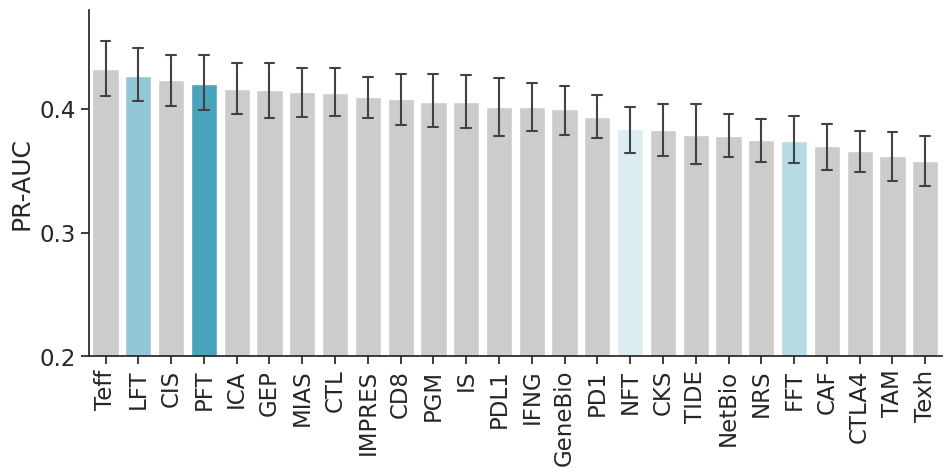

In [29]:
metric = 'PRC'
fig, ax = plt.subplots(figsize=(11,4.5))
x_order = data.groupby(['mode',])[metric].mean().sort_values(ascending=False).index.tolist()
sns.barplot(data=data, y = metric, x = 'mode', width=0.8, capsize=0.3, estimator=np.mean, errwidth = 1.5,
            #errorbar='se',
            order = x_order, ax=ax, palette=mode_palette)

ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax.set_ylim(0.2, 0.48)
ax.tick_params(axis='y', left=True)
ax.tick_params(axis='x', bottom=True)

ax.set_yticks(np.arange(0.2, 0.48, 0.1))
ax.set_ylabel('PR-AUC')
ax.set_xlabel('')
fig.savefig('./results/CTCT_PRC_barplot.svg', bbox_inches='tight')

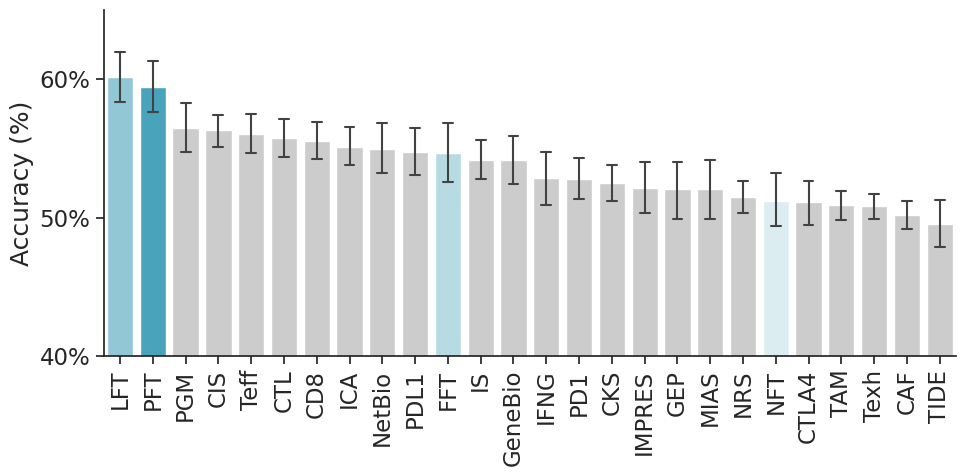

In [30]:
metric = 'ACC'
fig, ax = plt.subplots(figsize=(11,4.5))
x_order = data.groupby(['mode',])[metric].mean().sort_values(ascending=False).index.tolist()
sns.barplot(data=data, y = metric, x = 'mode', width=0.8, capsize=0.3, estimator=np.mean, errwidth = 1.5,
            #errorbar='se',
            order = x_order, ax=ax, palette=mode_palette)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax.set_ylim(0.4, 0.65)
ax.tick_params(axis='y', left=True)
ax.tick_params(axis='x', bottom=True)

ax.set_yticks(np.arange(0.4, 0.65, 0.1))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.set_ylabel('Accuracy (%)')
ax.set_xlabel('')
fig.savefig('./results/CTCT_ACC_barplot.svg', bbox_inches='tight')

Text(0.5, 0, '')

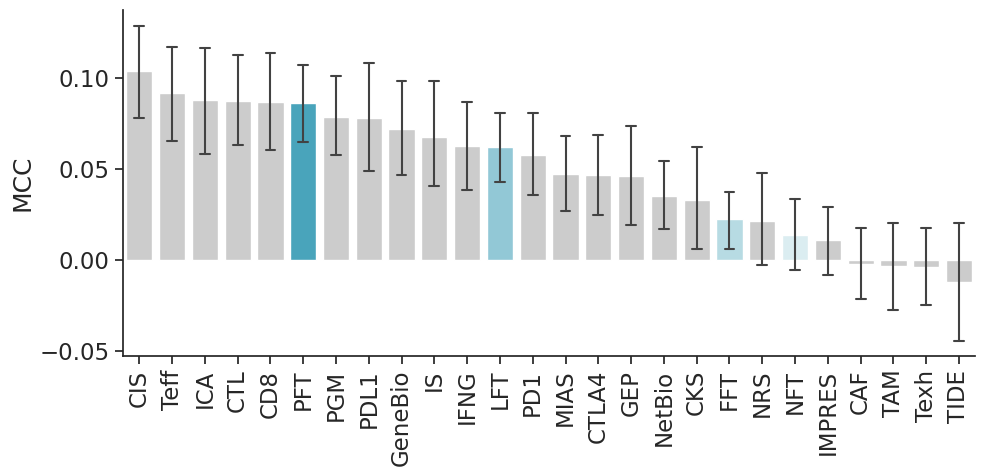

In [31]:
metric = 'MCC'
fig, ax = plt.subplots(figsize=(11,4.5))
x_order = data.groupby(['mode',])[metric].mean().sort_values(ascending=False).index.tolist()
sns.barplot(data=data, y = metric, x = 'mode', width=0.8, capsize=0.3, estimator=np.mean, errwidth = 1.5,
            #errorbar='se',
            order = x_order, ax=ax, palette=mode_palette)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

#ax.set_ylim(0.4, 0.65)
ax.tick_params(axis='y', left=True)
ax.tick_params(axis='x', bottom=True)

#ax.set_yticks(np.arange(0.4, 0.65, 0.1))
#ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.set_ylabel('MCC')
ax.set_xlabel('')
#fig.savefig('./results/CTCT_ACC_barplot.svg', bbox_inches='tight')

Text(0.5, 0, '')

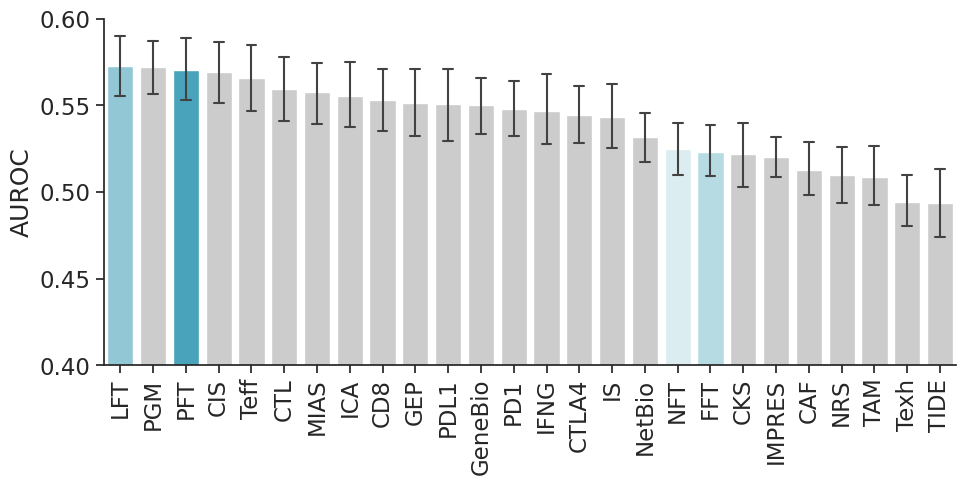

In [43]:
metric = 'ROC'
fig, ax = plt.subplots(figsize=(11,4.5))
x_order = data.groupby(['mode',])[metric].mean().sort_values(ascending=False).index.tolist()
sns.barplot(data=data, y = metric, x = 'mode', width=0.8, capsize=0.3, estimator=np.mean, errwidth = 1.5,
            #errorbar='se',
            order = x_order, ax=ax, palette=mode_palette)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax.set_ylim(0.4, 0.6)
ax.tick_params(axis='y', left=True)
ax.tick_params(axis='x', bottom=True)

#ax.set_yticks(np.arange(0.4, 0.65, 0.1))
#ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.set_ylabel('AUROC')
ax.set_xlabel('')
#fig.savefig('./results/CTCT_ACC_barplot.svg', bbox_inches='tight')

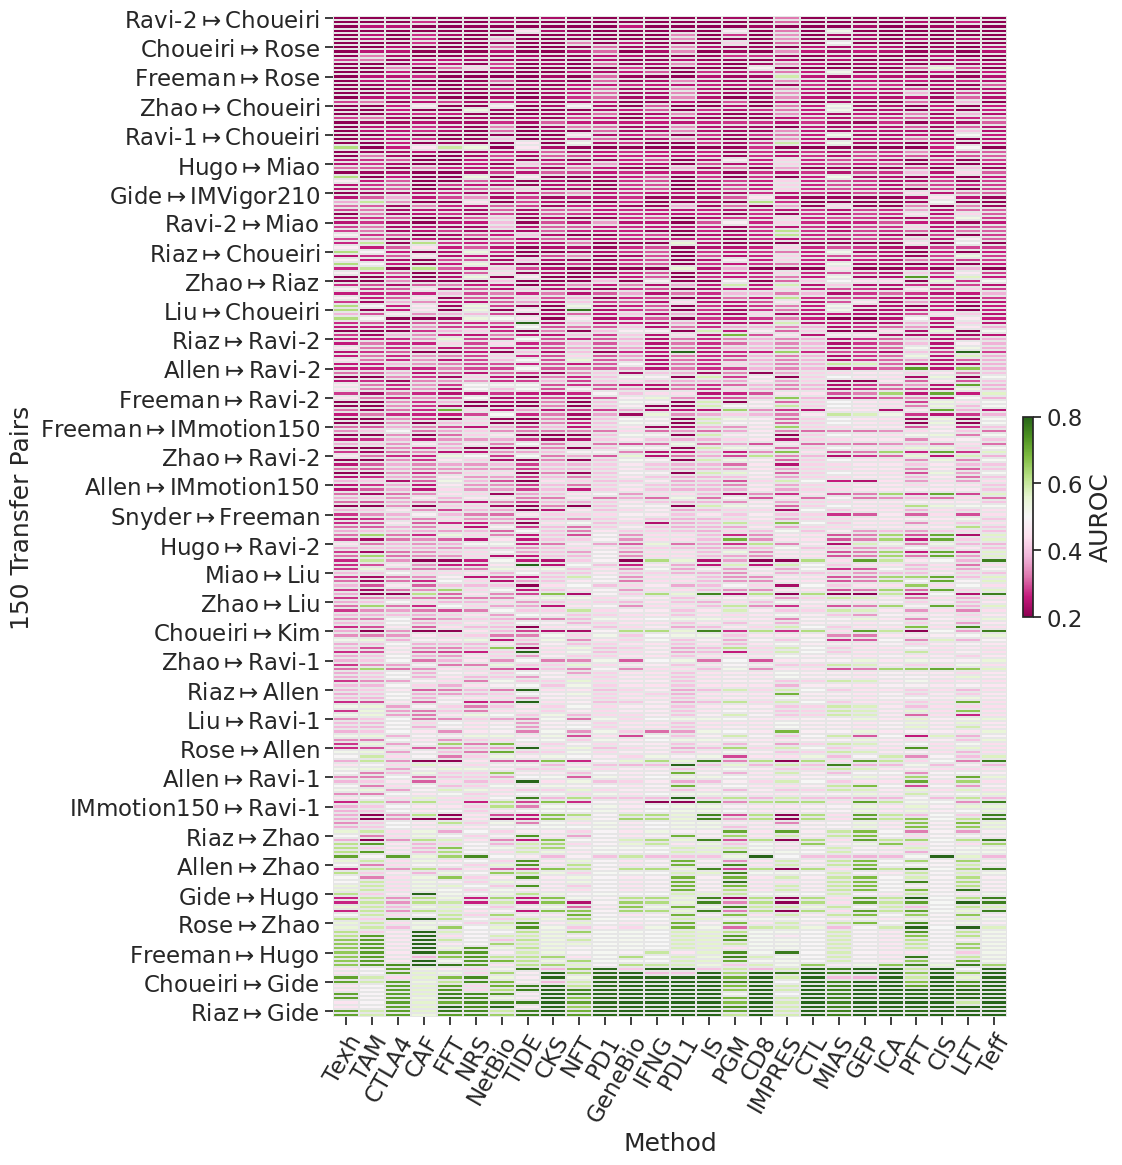

In [33]:
dfp = pd.pivot_table(data, columns = 'mode', index='transfer', values = 'PRC' )

x_order = dfp.mean().sort_values().index.tolist()
y_order = dfp.mean(axis=1).sort_values().index.tolist()

dfp = dfp[x_order].loc[y_order]

dfp.to_csv('./results/c2c_prc_raw.csv')


fig, ax = plt.subplots(figsize=(12, 12))

sns.heatmap(dfp, annot=False,
        cmap = 'PiYG', ax = ax, vmax = 0.8, vmin=0.2,
        cbar = False,
            
        # cbar_kws = dict(use_gridspec=True,
        #                 shrink=0.2, 
        #                 label = 'AUROC', 
        #                 location="right"), 
            
        linewidths=0.005, linecolor = '0.9')#


ax.tick_params(axis='both', which='major', right = False,
               top=False, direction = 'out',reset = True)
ax.set_xticklabels(
    x_order, 
    rotation=60, 
    ha="right",  
    rotation_mode="anchor")  # <====== HERE is the ke
ax.set_ylabel('150 Transfer Pairs')
ax.set_xlabel('Method')

fig.subplots_adjust(left=0.5)
fig.tight_layout()

cbar = ax.figure.colorbar(ax.collections[0], ax=ax, orientation='vertical', shrink=0.2, pad=0.02)
cbar.set_label("AUROC")

fig.savefig('./results/c2c_prc_heatmap.svg', bbox_inches='tight')
fig.savefig('./results/c2c_prc_heatmap.pdf', bbox_inches='tight')

In [34]:
ot = '#cccccc'

mode_palette = { 
                'CKS':ot, 'GEP':ot,  'MIAS':ot,'PDL1':ot,
                'Teff':ot, 'GeneBio':ot,
                'TIDE':ot, 'TAM':ot, 'Texh':ot, 'CAF':ot, 
                'NRS':ot, 'CTLA4':ot, 'IMPRES':ot, 'PGM':ot,
                'PD1':ot,  'NetBio':ot, 
                'CD8':ot, 'IS':ot, 'IFNG':ot, 'ICA':ot, 'CTL':ot, 'CIS':ot,
                }

compass_cmap = {'PFT':'#36AFCE', 'LFT':'#86CFE2','FFT':'#AFDFEB','NFT':'#D7EFF5', }
mode_palette.update(compass_cmap)

In [35]:
thr = 1.1
data_mt = data[(data.PRC > data.test_cohort_RPRC) ] #| (data.MCC > 0)
data_mt = data[(data.PRC_lift > thr) ] #| (data.MCC > 0)


df_mt = data_mt.groupby('mode').size().to_frame('# of Positive Transfer')

data_nt = data[(data.PRC <= data.test_cohort_RPRC) ] # | (data.MCC < 0)
data_nt = data[(data.PRC_lift <= thr) ] # | (data.MCC < 0)

df_nt = data_nt.groupby('mode').size().to_frame('# of Negative Transfer')

data['positive_transfer'] = data.index.isin(data_mt.index)
data['negative_transfer'] = data.index.isin(data_nt.index)

dft = df_mt.join(df_nt)
dft.sort_values('# of Positive Transfer', ascending=False)

,# of Positive Transfer,# of Negative Transfer
mode,,
CTL,167,73
Teff,167,73
ICA,166,74
CIS,161,79
LFT,154,86
PD1,154,86
CD8,152,88
PGM,152,88
PFT,147,93


In [36]:
data

,train_cohort,test_cohort,ROC,PRC,F1,ACC,MCC,mode,best_C,transfer,test_cohort_RGC,positive_transfer,negative_transfer,test_cohort_RPRC,PRC_lift
0,Allen,Choueiri,0.769231,0.532341,0.400000,0.437500,0.277350,NFT,NaN,Allen$\mapsto$Choueiri,0.695312,True,False,0.187500,2.839153
1,Allen,Gide,0.723485,0.723527,0.474576,0.575342,0.225134,NFT,NaN,Allen$\mapsto$Gide,0.504597,True,False,0.547945,1.320437
2,Allen,Hugo,0.339286,0.419693,0.482759,0.423077,-0.168175,NFT,NaN,Allen$\mapsto$Hugo,0.502959,False,True,0.538462,0.779431
3,Allen,IMVigor210,0.565345,0.286746,0.391753,0.604027,0.149696,NFT,NaN,Allen$\mapsto$IMVigor210,0.647764,True,False,0.228188,1.256624
4,Allen,IMmotion150,0.555912,0.321703,0.421769,0.484848,0.059924,NFT,NaN,Allen$\mapsto$IMmotion150,0.587438,True,False,0.290909,1.105853
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6235,Zhao,Riaz,0.668293,0.541837,0.352941,0.568627,0.128046,CIS,0.1,Zhao$\mapsto$Riaz,0.684737,True,False,0.196078,2.763370
6236,Zhao,Rose,0.590753,0.222209,0.307692,0.595506,0.091102,CIS,0.1,Zhao$\mapsto$Rose,0.705088,True,False,0.179775,1.236039
6237,Zhao,Ravi-1,0.607730,0.468074,0.522727,0.588235,0.177364,CIS,0.1,Zhao$\mapsto$Ravi-1,0.532488,True,False,0.372549,1.256409
6238,Zhao,Ravi-2,0.330882,0.245664,0.210526,0.400000,-0.262575,CIS,0.1,Zhao$\mapsto$Ravi-2,0.564800,False,True,0.320000,0.767700


In [37]:
dft.to_csv('./results/figure_2f_raw_data.csv')

In [38]:
df_mt.sort_values('# of Positive Transfer')

,# of Positive Transfer
mode,
TAM,72
TIDE,79
Texh,86
CAF,97
CTLA4,114
FFT,116
NRS,116
PDL1,121
NetBio,126


In [39]:
colors = sns.color_palette('PiYG',10)
mt_color = colors[-2]
nt_color = colors[1]

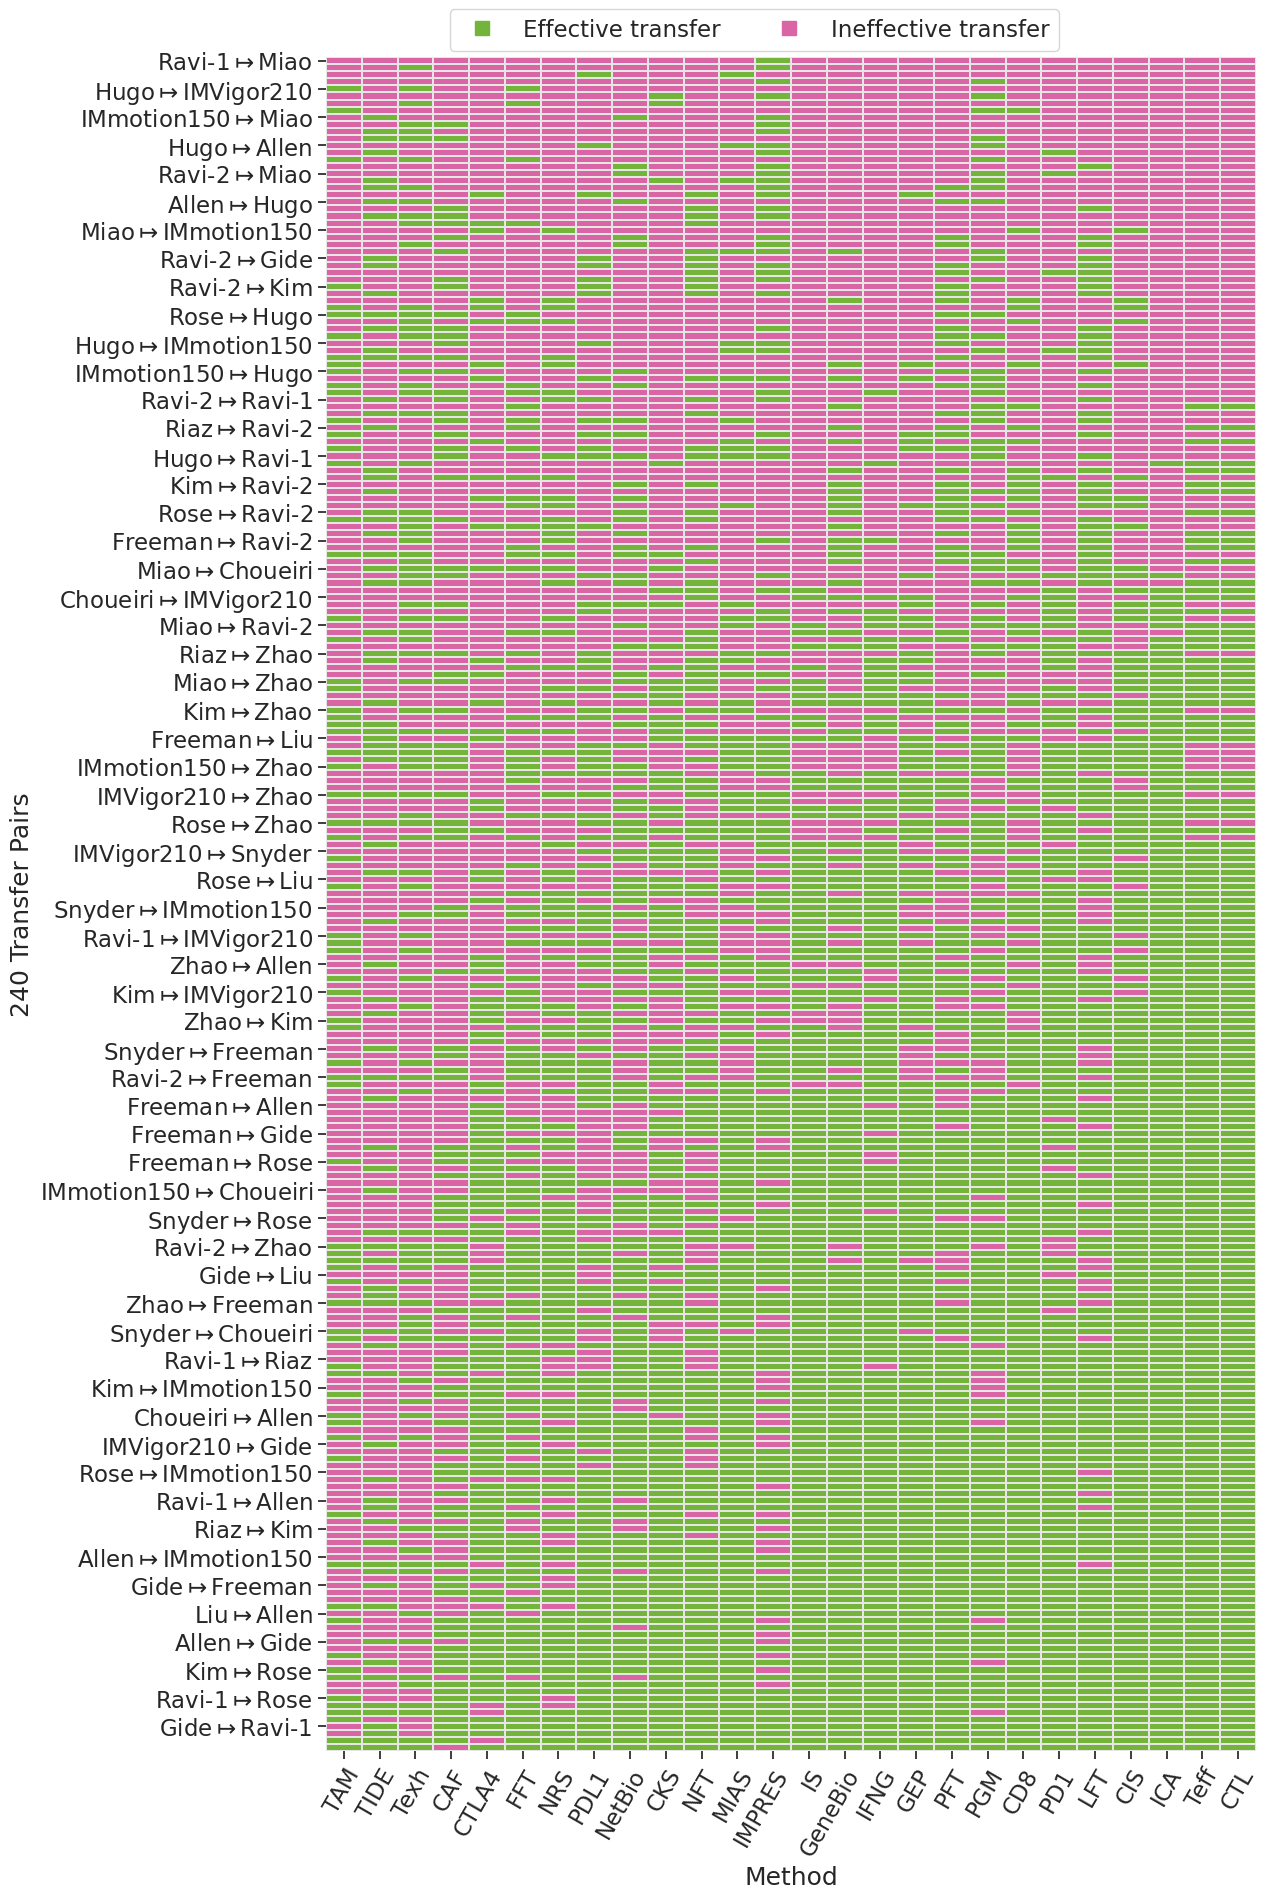

In [40]:
dfb1 = pd.pivot_table(data, columns = 'mode', index='transfer', values = 'positive_transfer' )
dfb1 = pd.DataFrame(np.where(dfb1 !=0, dfb1, np.nan), index=dfb1.index, columns= dfb1.columns)

dfb2 = pd.pivot_table(data, columns = 'mode', index='transfer', values = 'negative_transfer' )
dfb2 = pd.DataFrame(np.where(dfb2 !=0, dfb2, np.nan), index=dfb2.index, columns= dfb2.columns)


#x_order = dfb1.sum().sort_values().index
# y_order = dfb1.sum(axis=1).sort_values().index

x_order = ((dfb1.sum() - dfb2.sum())).sort_values().index #/ dfb2.sum()
l1 = dfb1[x_order[-6:]].sum(axis=1)
l2 = dfb2[x_order].sum(axis=1)

y_order = (l1-l2).sort_values().index


dfb1 = dfb1[x_order].loc[y_order]
dfb2 = dfb2[x_order].loc[y_order]

fig, ax = plt.subplots(figsize=(12, 22))
# sns.heatmap(dfb1, cmap = 'Greens', ax=ax, linewidths = 0.01)
cmap1 = sns.light_palette(mt_color, n_colors =  2, reverse=True)
cmap2 = sns.light_palette(nt_color, n_colors =  2, reverse=True)

sns.heatmap(dfb1, 
        cmap = cmap1, ax = ax, #vmax = data.max()-0.01,
        cbar=False,  #cbar_kws = dict(use_gridspec=False,location="bottom"), 
        linewidths=0.005, linecolor = '0.9')#

sns.heatmap(dfb2, 
        cmap = cmap2, ax = ax, #vmax = data.max()-0.01,
        cbar=False,  #cbar_kws = dict(use_gridspec=False,location="bottom"), 
        linewidths=0.005, linecolor = '0.9')#


ax.tick_params(axis='both', which='major', right = False, top=False, direction = 'out',reset = True)
ax.set_xticklabels(
    x_order, 
    rotation=60, 
    ha="right",  
    rotation_mode="anchor")  # <====== HERE is the ke
ax.set_ylabel('240 Transfer Pairs')
ax.set_xlabel('Method')


l1 = plt.plot([],[], marker="s", ms=10, ls="", mec=None, color=cmap1[0], label= 'Effective transfer' )[0]
l2 = plt.plot([],[], marker="s", ms=10, ls="", mec=None, color=cmap2[0], label= 'Ineffective transfer' )[0]
#l3 = plt.plot([],[], marker="s", ms=10, ls="", mec=None, color=cmap2[1], label= 'Ambigorious' )[0]

patches = [l1, l2,] # l3

ax.legend(handles=patches, bbox_to_anchor=(0.80,1.035),  
          loc='upper right', ncol=3, facecolor="w", numpoints=1, ) 


dfd_pos = dfb1.sum()/len(dfb1)
dfd_neg = dfb2.sum()/len(dfb2)

dfs_pos = dfb1.sum()
dfs_neg = dfb2.sum()

# fig.savefig('./results/all_pairs_heatmap.pdf', bbox_inches='tight')
# fig.savefig('./results/all_pairs_heatmap.svg', bbox_inches='tight')

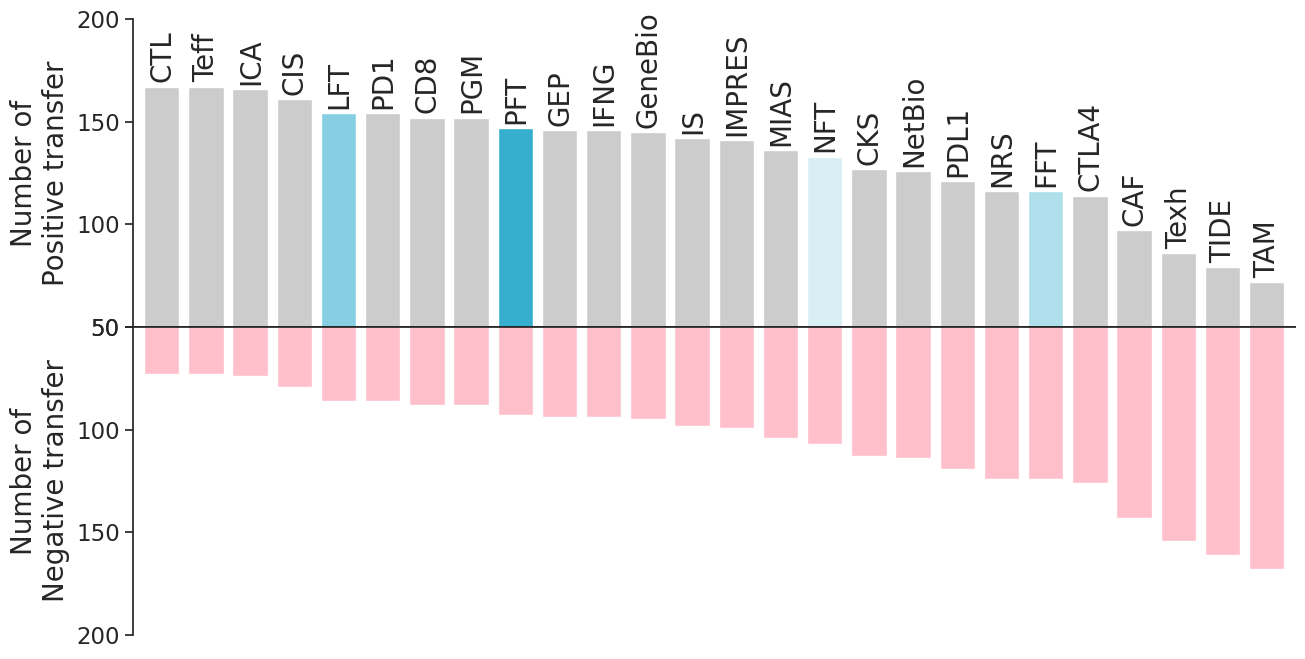

In [41]:
df_pos = pd.concat([dfs_pos], axis=1)
df_pos.columns = ['cohort2cohort']

df_neg = pd.concat([dfs_neg], axis=1)
df_neg.columns = ['cohort2cohort']

fig, axes = plt.subplots( nrows=2, ncols=1, sharey=False, figsize=(15,8))
ax1, ax4 = axes

fontsize = 20

### drug
sidx = list(x_order)
sidx.reverse() #dfs_neg.sort_values(ascending=True).index
dfp = dfs_pos.loc[sidx]

color = pd.Series(mode_palette).loc[dfp.index].to_list()
dfp.plot(kind='bar', color = color,ax=ax1, width=0.8)
i = 0
for k, y in dfp.items():
    ax1.text(i-0.3, y + 5, k, rotation=90, fontsize=fontsize)
    i += 1

dfs_neg.loc[dfp.index].plot(kind='bar', color = 'pink',ax=ax4, width=0.8)


for i, ax in enumerate( [ax1]):
    ax.set_ylim(50.,200)
    ax.set_xticks([])
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if i != 0:
        ax.spines["left"].set_visible(False)
        ax.get_yaxis().set_ticks([])

    ax.set_xlabel('')
    ax.yaxis.set_major_locator(MultipleLocator(50))


for i, ax in enumerate( [ax4]):
    ax.set_ylim(50.,200)
    
    ax.set_xticks([])
    ax.spines["bottom"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.invert_yaxis()
    
    if i != 0:
        ax.spines["left"].set_visible(False)
        ax.get_yaxis().set_ticks([])

    ax.set_xlabel('')
    ax.yaxis.set_major_locator(MultipleLocator(50))
    
ax1.set_ylabel('Number of\nPositive transfer', fontsize=fontsize)

vals = ax1.get_yticks()
#ax1.set_yticklabels(['{:,.0%}'.format(x) for x in vals])
ax1.tick_params(axis='y', which='major', right = False, top=False, direction = 'out',reset = True)


ax4.set_ylabel('Number of\nNegative transfer', fontsize=fontsize)
vals = ax4.get_yticks()
#ax4.set_yticklabels(['{:,.0%}'.format(x) for x in vals[:]])
ax4.tick_params(axis='y', which='major', right = False, top=False, direction = 'out',reset = True)
#ax1.set_title('cohort-to-cohort')
plt.subplots_adjust(wspace=0.1, hspace=0)
# plt.tight_layout()
